# 03 — Protocole repos (Resting HRV)

Le **protocole repos** est l'enregistrement HRV de référence : 5 minutes allongé au calme,
idéalement le matin au réveil avant toute activité. C'est la mesure la plus reproductible
et la base du score de readiness quotidien.

Ce notebook montre **deux voies d'accès aux données** :
- **Voie A — depuis un fichier** : parse → RRSeries → analyse → affichage (sans base de données)
- **Voie B — depuis la base** : charger l'historique → baseline → scoring → reporting

**Indicateurs clés :**
| Indicateur | Rôle clinique |
|---|---|
| RMSSD | Activité vagale (parasympathique) — le plus important |
| ln(RMSSD) | Version log-normalisée — plus stable entre individus |
| DFA α1 | Complexité du signal — fatigue si < 0.75 (Plews 2013) |
| Score | Readiness vs baseline personnelle [0–100] |

In [1]:
from pathlib import Path

from dotenv import load_dotenv

load_dotenv(Path("../.env"))

import matplotlib.pyplot as plt

import cardiolab
from cardiolab.analytics import Baseline, readiness_score_oura
from cardiolab.database import HRVRepository
from cardiolab.labels import LABELS_FR
from cardiolab.protocols import resting_hrv
from cardiolab.reporting import table_resting_history
from cardiolab.sensors_tools.polar import parse_rr_file
from cardiolab.signals.rr import RRSeries
from cardiolab.visualization.resting_plots import plot_resting_evolution

DATASETS_DIR = Path(cardiolab.__file__).parent / "datasets"
USER_ID_TEST = "demo-user"
print("✓  OK")

✓  OK


## Voie A — Depuis un fichier

Analyse complète d'une session unique sans base de données.
Idéal pour explorer un fichier reçu ou tester le pipeline.

In [2]:
# ── Charger et analyser une session ──────────────────────────────────────────
filepath = sorted((DATASETS_DIR / "raw" / "resting").glob("*.txt"))[0]
raw      = parse_rr_file(filepath)
rr       = RRSeries(raw["rr_intervals"]).remove_outliers()
features = resting_hrv(rr, compute_score=False)

print(f"Session : {filepath.stem}")
print(f"Durée   : {features.duration:.0f} s")
print()
print("─── Domaine temporel ────────────────────────")
print(f"  RMSSD    : {features.rmssd:.2f} ms  (norme repos: 20–60 ms)")
print(f"  ln(RMSSD): {features.ln_rmssd:.3f}")
print(f"  SDNN     : {features.sdnn:.2f} ms")
print(f"  pNN50    : {features.pnn50:.1f} %")
print(f"  HR moyen : {features.mean_hr:.1f} bpm")
print()
print("─── Domaine fréquentiel ─────────────────────")
print(f"  LF/HF    : {features.lf_hf:.2f}  (équilibre sympatho-vagal)")
print(f"  HF%      : {features.hf_pct:.1f} %  (activité parasympathique)")
print()
print("─── Non-linéaire ────────────────────────────")
print(f"  DFA α1   : {features.dfa_alpha1:.3f}  (> 1.0 = repos, < 0.75 = fatigue)")
print(f"  SD1      : {features.sd1:.2f} ms  (variabilité court terme = RMSSD/√2)")
print(f"  SD2      : {features.sd2:.2f} ms  (variabilité long terme)")

Session : 2026-04-24 07-52-36
Durée   : 332 s

─── Domaine temporel ────────────────────────
  RMSSD    : 78.46 ms  (norme repos: 20–60 ms)
  ln(RMSSD): 4.363
  SDNN     : 95.90 ms
  pNN50    : 17.6 %
  HR moyen : 57.9 bpm

─── Domaine fréquentiel ─────────────────────
  LF/HF    : 3.12  (équilibre sympatho-vagal)
  HF%      : 0.1 %  (activité parasympathique)

─── Non-linéaire ────────────────────────────
  DFA α1   : 0.978  (> 1.0 = repos, < 0.75 = fatigue)
  SD1      : 55.48 ms  (variabilité court terme = RMSSD/√2)
  SD2      : 123.76 ms  (variabilité long terme)


## Voie B — Depuis la base de données

Charger l'historique complet, construire la baseline personnelle progressivement,
calculer le score de readiness et générer le reporting.

In [3]:
# ── Charger l'historique depuis la base ──────────────────────────────────────
with HRVRepository.from_env() as repo:
    history = repo.load_features(USER_ID_TEST)

if not history:
    print("⚠️  Aucune session en base — exécutez d'abord le notebook 02_import_pipeline")
else:
    print(f"{len(history)} sessions chargées depuis la base")

    # Construire la baseline progressive (session N scored vs sessions 1…N-1)
    baseline = Baseline()
    scores   = []
    dates    = []
    for feat in history:
        score = readiness_score_oura(feat, baseline)
        feat.score = score
        scores.append(score)
        dates.append(str(feat.date))
        baseline.history.append(feat)

    print(f"\n{'Date':<12} {'RMSSD':>8} {'DFA α1':>8} {'Score':>7} Interprétation")
    print("-" * 58)
    for feat, score in zip(history, scores):
        interp = (
            "Excellent" if score >= 65 else
            "Bonne récup." if score >= 55 else
            "Normal" if score >= 45 else
            "Légère fatigue" if score >= 35 else
            "Fatigue élevée"
        )
        print(f"  {str(feat.date):<10}  {feat.rmssd:>6.1f} ms  "
              f"{feat.dfa_alpha1:>6.3f}  {score:>5.0f}/100  {interp}")

6 sessions chargées depuis la base

Date            RMSSD   DFA α1   Score Interprétation
----------------------------------------------------------
  2026-04-24    78.5 ms   0.978     50/100  Normal
  2026-04-25    51.8 ms   1.280     37/100  Légère fatigue
  2026-04-26    53.5 ms   1.195     38/100  Légère fatigue
  2026-04-27    52.6 ms   1.069     51/100  Normal
  2026-04-28    59.9 ms   0.952     60/100  Bonne récup.
  2026-04-30    81.9 ms   1.071     83/100  Excellent


## Reporting — Tableau couleur

In [4]:
if history:
    styler = table_resting_history(
        history,
        labels=LABELS_FR,
        cols=["date", "rmssd", "ln_rmssd", "mean_hr", "dfa_alpha1", "sd1", "sd2", "score"],
    )
    display(styler)

,Date,RMSSD (ms),ln(RMSSD),FC (bpm),DFA α1,SD1 (ms),SD2 (ms),Score de forme
0,2026-04-24,78.5,4.4,57.9,0.978,55.5,123.8,50.0
1,2026-04-25,51.8,3.9,52.2,1.280,36.6,148.7,37.0
2,2026-04-26,53.5,4.0,55.3,1.195,37.9,150.6,37.7
3,2026-04-27,52.6,4.0,53.5,1.069,37.2,102.2,51.1
4,2026-04-28,59.9,4.1,53.9,0.952,42.4,115.1,60.1
5,2026-04-30,81.9,4.4,51.0,1.071,57.9,149.2,82.6


## Visualisation — Évolution du RMSSD et du score dans le temps

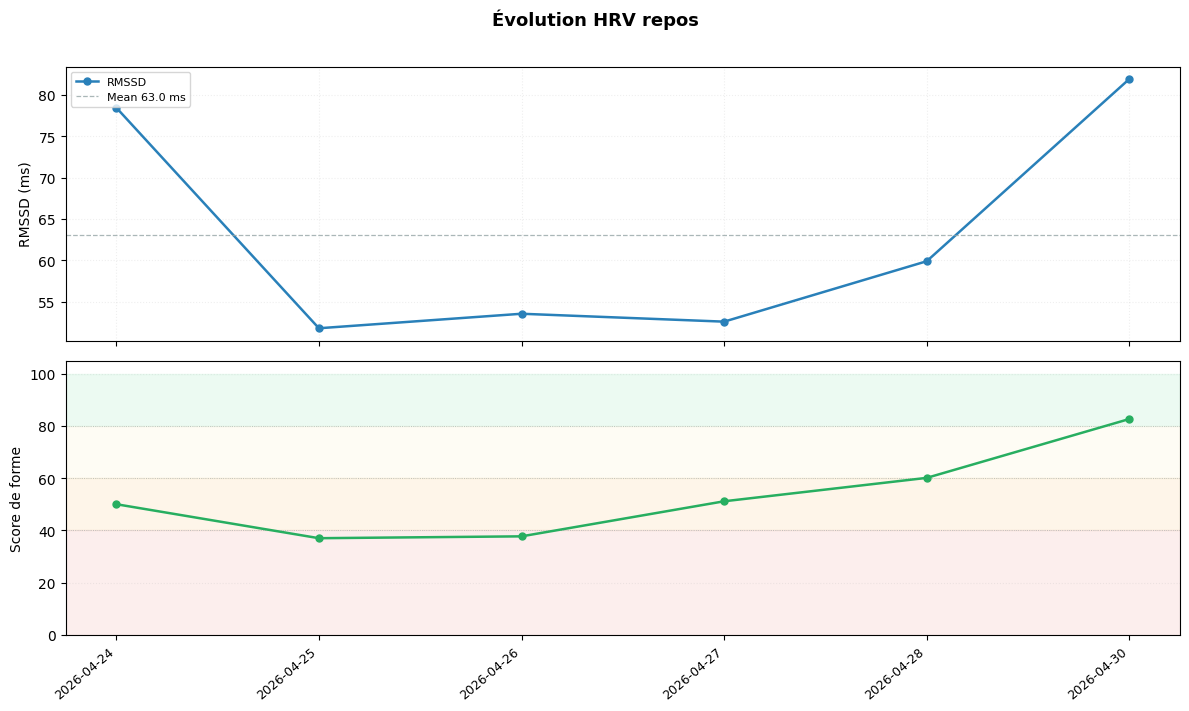

In [5]:
if history:
    fig = plot_resting_evolution(
        history, scores,
        session_labels=dates,
        labels=LABELS_FR,
        title="Évolution HRV repos",
    )
    plt.show()

## Export

Exporter le tableau en HTML ou Excel pour partage.

In [6]:
if history:
    output_html = Path("../notebooks/resting_history.html")
    styler.to_html(output_html)
    print(f"✓  Rapport HTML exporté : {output_html.resolve()}")

    # Export CSV via io module
    from cardiolab.io import features_to_csv
    output_csv = Path("../notebooks/resting_history.csv")
    features_to_csv(history, output_csv)
    print(f"✓  CSV exporté : {output_csv.resolve()}")

✓  Rapport HTML exporté : /home/jmilon/Projet-Pro-DevSecOps/Programmation/GitLab/cardioanalysis/cardiolab/notebooks/resting_history.html
✓  CSV exporté : /home/jmilon/Projet-Pro-DevSecOps/Programmation/GitLab/cardioanalysis/cardiolab/notebooks/resting_history.csv
